# 📈 10_monitoramento_pipeline — Saúde do pipeline de `ecommerce_pedidos`
**Squad 2 · Dupla 3** · ferramenta de observabilidade, **somente leitura** (não grava nada)

Responde, para as últimas `HORAS` horas, às perguntas de quem opera o pipeline: a fonte está mandando dados? cada camada está em dia com a anterior?
os ciclos estão falhando ou ficando lentos? a qualidade está piorando? quanto tempo um pedido leva do gerador à Silver? quantos alertas saíram?

| Etapa | Pergunta | Indicador |
|---|---|---|
| 1 | — | Configuração e limites |
| 2 | A fonte está ativa e tudo do `raw` tem destino? | minutos desde o último micro-lote · arquivos sem destino · arquivos recusados |
| 3 | Cada camada está em dia com a anterior? | última atualização de Bronze, Silver e Gold · idade do dado que o painel mostra |
| 4 | Os ciclos estão saudáveis? | ciclos com erro na última execução (❌) e nas anteriores (⚠️) · duração mediana e p95 por etapa |
| 5 | A qualidade está piorando? | taxa de quarentena por hora e motivos |
| 6 | Quanto tempo um pedido leva para chegar? | latência p95 do gerador à Silver na última execução · pedidos tardios (depois do *watermark*) |
| 7 | O que a Gold avisou? | alertas por regra e por hora |
| 8 | Veredito | painel de saúde com ✅ / ⚠️ / ❌ e gráficos |

Cada etapa **faz** e **valida**: ✅ dentro do limite · ⚠️ fora do limite, sem perda de dado · ❌ inconsistência que exige ação.
Rode durante e depois de cada janela de tempo real; os limites ficam na Etapa 1.

## Etapa 1 — Configuração e limites
**Faz:** carrega o `00_setup_config` em modo rápido e define a janela observada e os limites de cada indicador.
**Valida:** se a Bronze existe.

In [0]:
VALIDACAO_COMPLETA = False

In [0]:
%run ./00_setup_config

# ⚙️ 00_setup_config — Configuração central
**Squad 2 · Dupla 3 · `ecommerce_pedidos`**

Prepara endereços, credenciais, conexões e funções usadas por todo o pipeline. **Não lê nem grava pedidos.**

Cada etapa **faz o trabalho e valida em seguida**: ✅ ok · ⚠️ aviso (segue) · ❌ erro (para e explica).

**Uso nos outros notebooks** (duas células; o `%run` fica sozinho):
```
VALIDACAO_COMPLETA = False
```
```
%run ./00_setup_config
```
Dependências em **Environment → Dependencies**: `azure-identity`, `azure-storage-file-datalake`.

## Etapa 1 — Ambiente e endereços
**Faz:** cria a função `checar` e guarda os nomes fixos do projeto.
**Valida:** se está no Databricks e se origem e destino são containers diferentes.

Modo de validação: RÁPIDA
✅ Rodando no Databricks
✅ Origem (raw) e destino (squad2) separados


## Etapa 2 — Credenciais
**Faz:** busca as 7 chaves no Secret Scope. Ficam só na memória (aparecem como `[REDACTED]` se impressas).
**Valida:** se o cofre existe, se nenhuma chave falta e se o host do SQL tem o formato certo.

✅ Cofre 'mercadata-ecommerce-pedidos' encontrado
✅ 7 credenciais carregadas (valores ocultos)
✅ SQL_HOST no formato do Azure SQL


...

✅ url_origem OK
✅ tabela_delta_existe OK (Bronze já existe)
✅ ler_metadata OK (None para anotação inexistente)
✅ versao_delta OK (Bronze na versão 49)
✅ trava_ativa OK (orquestrador rodando: orquestrador_20261008_194726)


## Etapa 6 — Funções do SQL Server
**Faz:** cria as funções de gravar e consultar o banco. Gravação pelo conector `sqlserver` (o `jdbc` é bloqueado no Serverless); leitura pelo `jdbc`.
**Valida:** se toda tabela recebe o schema `squad2`.

✅ Tabelas SQL vão para o schema 'squad2'


## Etapa 7 — Teste completo (só ao rodar este notebook direto)
**Faz e valida:** varre o `raw` · lê o micro-lote mais recente e confere colunas e tipos (regra 1) · grava e relê em `metadata/` · `SELECT 1` no SQL Server · confere se o schema `squad2` existe no banco.
No modo rápido (`%run`), é pulada. No fim, limpa as variáveis temporárias.

Teste completo pulado (modo rápido).
⚙️ 00_setup_config pronto para uso


In [0]:
import re
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

HORAS = 24                                   # janela observada
LIMITES = {
    "fonte_parada_min": 15,                  # sem micro-lote novo há mais que isso: gerador parado (ou fora da janela)
    "camada_atrasada_min": 10,               # uma camada mais velha que a anterior além disso: pipeline atrasado
    "duracao_ciclo_p95_s": 300,              # ciclo com dados mais lento que isso: latência fora do aceitável
    "latencia_silver_p95_s": 600,            # do horário da pasta do gerador até a Silver
    "quarentena_hora_pct": 15,               # taxa de quarentena numa hora acima disso: fonte degradada
}
contrato = ler_metadata("eda_raw") or {}
FUSO_HORAS = int((contrato.get("fuso") or {}).get("horas_ate_utc", 3))      # horário do gerador -> UTC
WATERMARK_S = int((contrato.get("gold") or {}).get("watermark_s", 120))
PADRAO_JANELA = r"(\d{4}/\d{2}/\d{2}/\d{6})"                              # pasta do micro-lote: AAAA/MM/DD/HHMMSS
ETAPAS = {"./03_ingestao_bronze": "bronze", "./04_ingestao_silver": "silver", "./05_ingestao_gold": "gold"}
AGORA = pd.Timestamp.now(tz="UTC").tz_localize(None)
INICIO = AGORA - pd.Timedelta(hours=HORAS)

saude = []
def avaliar(area, indicador, valor, ok, critico=False):
    """Uma linha do painel de saúde: ✅ ok · ⚠️ fora do limite · ❌ inconsistência (critico=True)."""
    situacao = "✅" if ok else ("❌" if critico else "⚠️")
    saude.append({"area": area, "indicador": indicador, "valor": str(valor), "situacao": situacao})
    print(f"{situacao} {area} · {indicador}: {valor}")


def janela_utc(caminhos):
    """Horário de criação de cada micro-lote (nome da pasta, horário do gerador) convertido para UTC."""
    serie = pd.Series(list(caminhos), dtype="object")
    return pd.to_datetime(serie.str.extract(PADRAO_JANELA)[0], format="%Y/%m/%d/%H%M%S") + pd.Timedelta(hours=FUSO_HORAS)


# ------------------------------ validação ------------------------------
checar(tabela_delta_existe(CAMINHO_BRONZE), "Bronze encontrada", "Bronze não existe: nada para monitorar")
print(f"Janela observada: {INICIO:%Y-%m-%d %H:%M} a {AGORA:%Y-%m-%d %H:%M} UTC · fuso do gerador +{FUSO_HORAS} h · watermark {WATERMARK_S} s")

✅ Bronze encontrada
Janela observada: 2026-10-07 20:04 a 2026-10-08 20:04 UTC · fuso do gerador +3 h · watermark 120 s


## Etapa 2 — Fonte e ingestão
**Faz:** lê o horário de cada micro-lote pelo nome da pasta, conta os micro-lotes por hora e cruza o `raw` com a Bronze e com os recusados.
**Valida:** a fonte mandou dado recentemente (⚠️ se não: pode ser só fora da janela) · nenhum arquivo do `raw` sem destino · nenhum arquivo recusado.

In [0]:
no_raw = listar_arquivos_origem()
ignorados = ler_metadata("bronze_ignorados") or {}
na_bronze = {r[0] for r in ler_delta(CAMINHO_BRONZE).select("bronze_source_file").distinct().collect()}
sem_destino = sorted(set(no_raw) - na_bronze - set(ignorados))

lotes = pd.DataFrame({"arquivo": no_raw, "janela_utc": janela_utc(no_raw)})
ultimo_lote = lotes["janela_utc"].max()
minutos_sem_lote = round((AGORA - ultimo_lote).total_seconds() / 60, 1) if pd.notna(ultimo_lote) else None
recentes = lotes[lotes["janela_utc"] >= INICIO]
fonte_por_hora = recentes.groupby(recentes["janela_utc"].dt.floor("h")).size().rename("micro_lotes").reset_index()

# ------------------------------ validação ------------------------------
avaliar("Fonte", "minutos desde o último micro-lote", minutos_sem_lote,
        minutos_sem_lote is not None and minutos_sem_lote <= LIMITES["fonte_parada_min"])
avaliar("Ingestão", "micro-lotes do raw sem destino (nem Bronze, nem recusados)", len(sem_destino), not sem_destino)
avaliar("Ingestão", "micro-lotes recusados pela Bronze (total)", len(ignorados), not ignorados)

# ------------------------------ resultado ------------------------------
print(f"{len(no_raw)} micro-lotes no raw · {len(recentes)} nas últimas {HORAS} h · último: {ultimo_lote} UTC")
if ignorados:
    display(pd.DataFrame(list(ignorados.items()), columns=["arquivo", "motivo"]))

✅ Fonte · minutos desde o último micro-lote: 4.7
✅ Ingestão · micro-lotes do raw sem destino (nem Bronze, nem recusados): 0
✅ Ingestão · micro-lotes recusados pela Bronze (total): 0
353 micro-lotes no raw · 157 nas últimas 24 h · último: 2026-10-08 20:00:02 UTC


## Etapa 3 — Frescor por camada
**Faz:** pega a última gravação de cada camada (Bronze: `bronze_ingested_at`; Silver e quarentena: `silver_processed_at`; Gold: `ultimo_ciclo_id`)
e a idade do pedido mais recente que os KPIs mostram (`referencia` do `gold_controle`).
**Valida:** Silver em dia com a Bronze e Gold em dia com a Silver (❌ se uma camada ficou para trás: um notebook falhou ou não rodou).

In [0]:
def maximo(caminho, coluna):
    return ler_delta(caminho).agg(F.max(coluna)).first()[0] if tabela_delta_existe(caminho) else None


controle_gold = ler_metadata("gold_controle") or {}
ultima = {
    "Bronze": maximo(CAMINHO_BRONZE, "bronze_ingested_at"),
    "Silver": max([v for v in (maximo(CAMINHO_SILVER, "silver_processed_at"), maximo(CAMINHO_QUARANTINE, "silver_processed_at")) if v], default=None),
    "Gold": pd.to_datetime(str(controle_gold.get("ultimo_ciclo_id", "")), format="%Y%m%d%H%M%S", errors="coerce"),
}
frescor = pd.DataFrame([(k, pd.Timestamp(v) if v is not None and pd.notna(v) else pd.NaT) for k, v in ultima.items()],
                       columns=["camada", "ultima_gravacao_utc"])
frescor["idade_min"] = ((AGORA - frescor["ultima_gravacao_utc"]).dt.total_seconds() / 60).round(1)
referencia = pd.to_datetime(controle_gold.get("referencia"), errors="coerce")         # pedido mais recente nos KPIs (Brasília)
idade_kpi_min = round((AGORA - pd.Timedelta(hours=FUSO_HORAS) - referencia).total_seconds() / 60, 1) if pd.notna(referencia) else None


def em_dia(posterior, anterior):
    """A camada posterior gravou depois da anterior (ou no máximo LIMITE minutos antes)."""
    a, b = ultima[posterior], ultima[anterior]
    if b is None or pd.isna(b):
        return True
    return a is not None and pd.notna(a) and (pd.Timestamp(b) - pd.Timestamp(a)).total_seconds() / 60 <= LIMITES["camada_atrasada_min"]


# ------------------------------ validação ------------------------------
avaliar("Frescor", "Silver em dia com a Bronze", f"Silver {ultima['Silver']} · Bronze {ultima['Bronze']}", em_dia("Silver", "Bronze"), critico=True)
avaliar("Frescor", "Gold em dia com a Silver", f"Gold {ultima['Gold']} · Silver {ultima['Silver']}", em_dia("Gold", "Silver"), critico=True)
avaliar("Frescor", "idade do pedido mais recente mostrado nos KPIs (min)", idade_kpi_min,
        idade_kpi_min is not None and idade_kpi_min <= LIMITES["fonte_parada_min"])

# ------------------------------ resultado ------------------------------
display(frescor.astype({"ultima_gravacao_utc": str}))

✅ Frescor · Silver em dia com a Bronze: Silver 2026-10-08 20:00:48.377687 · Bronze 2026-10-08 20:00:37.811849
✅ Frescor · Gold em dia com a Silver: Gold 2026-10-08 20:00:52 · Silver 2026-10-08 20:00:48.377687
✅ Frescor · idade do pedido mais recente mostrado nos KPIs (min): 5.5


camada,ultima_gravacao_utc,idade_min
Bronze,2026-10-08 20:00:37.811849,4.1
Silver,2026-10-08 20:00:48.377687,4.0
Gold,2026-10-08 20:00:52.000000,3.9


## Etapa 4 — Ciclos do orquestrador
**Faz:** lê os registros `orquestrador_AAAAMMDD_HHMMSS.json` das últimas horas e monta uma linha por ciclo, com o status e a duração de cada etapa.
**Valida:** nenhum ciclo com erro na **última execução** (❌: o pipeline atual está falhando) · erros de execuções **anteriores** viram ⚠️ (histórico:
já não dizem como o pipeline está agora) · duração p95 dos ciclos com dados dentro do limite.

In [0]:
nomes = sorted(p.name.rsplit("/", 1)[1][:-5] for p in fs_squad.get_paths(path=f"metadata/{TABELA}", recursive=False)
               if re.fullmatch(r"orquestrador_\d{8}_\d{6}\.json", p.name.rsplit("/", 1)[1]))      # a trava fica de fora
execucoes = [n for n in nomes if pd.to_datetime(n.split("_", 1)[1], format="%Y%m%d_%H%M%S") >= INICIO - pd.Timedelta(hours=3)]

linhas = []
for execucao in execucoes:
    for r in (ler_metadata(execucao) or {}).get("ciclos", []):
        linha = {"execucao": execucao, "ciclo": r["ciclo"], "inicio_utc": pd.Timestamp(r["inicio_utc"]).tz_convert(None)}
        for notebook, etapa in ETAPAS.items():
            linha[f"{etapa}_status"] = r.get(notebook, {}).get("status", "—")
            linha[f"{etapa}_s"] = r.get(notebook, {}).get("duracao_s", 0)
        linha["arquivos_novos"] = r.get("./03_ingestao_bronze", {}).get("resumo", {}).get("arquivos_gravados", 0)
        linhas.append(linha)
colunas = ["execucao", "ciclo", "inicio_utc", "arquivos_novos"] + [f"{e}_{c}" for e in ETAPAS.values() for c in ("status", "s")]
ciclos = pd.DataFrame(linhas, columns=colunas)
ciclos = ciclos[ciclos["inicio_utc"] >= INICIO] if len(ciclos) else ciclos
ciclos["duracao_s"] = ciclos[[f"{e}_s" for e in ETAPAS.values()]].sum(axis=1) if len(ciclos) else []
com_erro = ciclos[(ciclos[[f"{e}_status" for e in ETAPAS.values()]] == "ERRO").any(axis=1)] if len(ciclos) else ciclos
com_dados = ciclos[ciclos["arquivos_novos"] > 0] if len(ciclos) else ciclos
p95_ciclo = round(float(com_dados["duracao_s"].quantile(0.95)), 1) if len(com_dados) else None
ULTIMA_EXECUCAO = ciclos["execucao"].max() if len(ciclos) else None          # nome com data e hora: o maior é o mais recente
INICIO_ULTIMA = pd.to_datetime(ULTIMA_EXECUCAO.split("_", 1)[1], format="%Y%m%d_%H%M%S") if ULTIMA_EXECUCAO else None
erros_ultima = com_erro[com_erro["execucao"] == ULTIMA_EXECUCAO] if len(com_erro) else com_erro
erros_anteriores = com_erro[com_erro["execucao"] != ULTIMA_EXECUCAO] if len(com_erro) else com_erro

# ------------------------------ validação ------------------------------
avaliar("Orquestração", f"ciclos nas últimas {HORAS} h (com dados)", f"{len(ciclos)} ({len(com_dados)})", True)
avaliar("Orquestração", f"ciclos com erro na última execução ({ULTIMA_EXECUCAO or 'nenhuma'})", len(erros_ultima), erros_ultima.empty, critico=True)
avaliar("Orquestração", "ciclos com erro em execuções anteriores (histórico)", len(erros_anteriores), erros_anteriores.empty)
avaliar("Orquestração", "duração p95 dos ciclos com dados (s)", p95_ciclo, p95_ciclo is None or p95_ciclo <= LIMITES["duracao_ciclo_p95_s"])

# ------------------------------ resultado ------------------------------
if len(com_dados):
    duracoes = pd.DataFrame({e: com_dados[f"{e}_s"].describe(percentiles=[0.5, 0.95])[["50%", "95%", "max"]] for e in ETAPAS.values()}).T
    display(duracoes.rename(columns={"50%": "p50_s", "95%": "p95_s", "max": "max_s"}).round(1).reset_index().rename(columns={"index": "etapa"}))
display(com_erro) if len(com_erro) else print("Nenhum ciclo com erro na janela observada.")

✅ Orquestração · ciclos nas últimas 24 h (com dados): 23 (14)
✅ Orquestração · ciclos com erro na última execução (orquestrador_20261008_194726): 0
⚠️ Orquestração · ciclos com erro em execuções anteriores (histórico): 5
✅ Orquestração · duração p95 dos ciclos com dados (s): 137.8


etapa,p50_s,p95_s,max_s
bronze,6.3,9.7,10.6
silver,14.6,18.0,19.8
gold,66.8,114.5,167.3


execucao,ciclo,inicio_utc,arquivos_novos,bronze_status,bronze_s,silver_status,silver_s,gold_status,gold_s,duracao_s
orquestrador_20261008_173826,1,2026-10-08T17:38:28.000Z,0,ERRO,584.3,PULADO,0.0,PULADO,0.0,584.3
orquestrador_20261008_173826,2,2026-10-08T17:49:12.000Z,0,ERRO,31.5,PULADO,0.0,PULADO,0.0,31.5
orquestrador_20261008_173826,3,2026-10-08T17:50:44.000Z,0,ERRO,31.1,PULADO,0.0,PULADO,0.0,31.1
orquestrador_20261008_183032,1,2026-10-08T18:30:34.000Z,0,ERRO,21.7,PULADO,0.0,PULADO,0.0,21.7
orquestrador_20261008_183032,2,2026-10-08T18:31:55.000Z,0,ERRO,21.3,PULADO,0.0,PULADO,0.0,21.3


## Etapa 5 — Qualidade ao longo do tempo
**Faz:** conta, por hora de processamento, os pedidos aprovados e os da quarentena, e os motivos da quarentena na janela observada.
**Valida:** nenhuma hora com taxa de quarentena acima do limite (⚠️: sinal de degradação da fonte, não de erro do pipeline).

In [0]:
def por_hora(caminho, rotulo):
    """Pedidos por hora de processamento num destino da Silver (tabela vazia, já com a hora tipada, se o destino não existe)."""
    if not tabela_delta_existe(caminho):
        return pd.DataFrame({"hora": pd.Series(dtype="datetime64[ns]"), rotulo: pd.Series(dtype="int64")})
    pdf = (ler_delta(caminho).filter(F.col("silver_processed_at") >= F.lit(INICIO.to_pydatetime()))
           .groupBy(F.date_trunc("hour", "silver_processed_at").alias("hora")).agg(F.count("*").alias(rotulo)).toPandas())
    return pdf.assign(hora=pd.to_datetime(pdf["hora"]))          # o merge exige o mesmo tipo de hora nos dois lados


qualidade = por_hora(CAMINHO_SILVER, "aprovados").merge(por_hora(CAMINHO_QUARANTINE, "quarentena"), on="hora", how="outer").fillna(0)
qualidade[["aprovados", "quarentena"]] = qualidade[["aprovados", "quarentena"]].astype(int)
qualidade["taxa_pct"] = (qualidade["quarentena"] / (qualidade["aprovados"] + qualidade["quarentena"]).where(lambda t: t > 0) * 100).round(1)
qualidade = qualidade.sort_values("hora")
motivos = (ler_delta(CAMINHO_QUARANTINE).filter(F.col("silver_processed_at") >= F.lit(INICIO.to_pydatetime()))
           .select(F.explode(F.split("motivo_quarentena", ", ")).alias("motivo")).groupBy("motivo").count()
           .orderBy(F.desc("count")).toPandas()) if tabela_delta_existe(CAMINHO_QUARANTINE) else pd.DataFrame(columns=["motivo", "count"])
horas_ruins = qualidade[qualidade["taxa_pct"] > LIMITES["quarentena_hora_pct"]]

# ------------------------------ validação ------------------------------
total = int(qualidade["aprovados"].sum() + qualidade["quarentena"].sum())
avaliar("Qualidade", f"taxa de quarentena nas últimas {HORAS} h (%)",
        round(qualidade["quarentena"].sum() / total * 100, 1) if total else None, True)
avaliar("Qualidade", f"horas com quarentena acima de {LIMITES['quarentena_hora_pct']}%", len(horas_ruins), horas_ruins.empty)

# ------------------------------ resultado ------------------------------
display(qualidade.astype({"hora": str})) if len(qualidade) else print("Nenhum pedido processado na janela observada.")
display(motivos) if len(motivos) else None

✅ Qualidade · taxa de quarentena nas últimas 24 h (%): 28.2
⚠️ Qualidade · horas com quarentena acima de 15%: 2


hora,aprovados,quarentena,taxa_pct
2026-10-08 18:00:00,621,228,26.9
2026-10-08 19:00:00,83,49,37.1
2026-10-08 20:00:00,1,0,0.0


motivo,count
regra5_status_fora_do_enum,232
regra10_atualizacao_antes_do_pedido,50
regra3_valor_total_nao_positivo,12


## Etapa 6 — Latência por micro-lote
**Faz:** para cada micro-lote ingerido na janela: horário da pasta do gerador (UTC) → `bronze_ingested_at` → `silver_processed_at`.
A latência que vale é a dos micro-lotes gerados **durante a última execução do orquestrador** (o tempo real de fato); a das últimas horas inteiras inclui
arquivos que esperaram o pipeline voltar a rodar e fica como informação.
Conta também os pedidos **tardios** (atraso de chegada maior que o *watermark* da Gold): entram nos KPIs, mas não reabrem janelas já fechadas.
**Valida:** latência p95 até a Silver na última execução dentro do limite · pedidos tardios (⚠️ se houver: comportamento da fonte, não erro do pipeline).

In [0]:
bronze_janela = ler_delta(CAMINHO_BRONZE).filter(F.col("bronze_ingested_at") >= F.lit(INICIO.to_pydatetime()))
por_arquivo = bronze_janela.groupBy("bronze_source_file").agg(F.max("bronze_ingested_at").alias("bronze_utc"), F.count("*").alias("pedidos"))
for caminho, rotulo in [(CAMINHO_SILVER, "silver_utc"), (CAMINHO_QUARANTINE, "quarentena_utc")]:
    if tabela_delta_existe(caminho):
        destino = (ler_delta(caminho).filter(F.col("silver_processed_at") >= F.lit(INICIO.to_pydatetime()))
                   .groupBy("bronze_source_file").agg(F.max("silver_processed_at").alias(rotulo)))
        por_arquivo = por_arquivo.join(destino, "bronze_source_file", "left")
latencia = por_arquivo.toPandas()
if len(latencia):
    latencia["janela_utc"] = janela_utc(latencia["bronze_source_file"]).values
    processado = latencia[[c for c in ("silver_utc", "quarentena_utc") if c in latencia]].apply(pd.to_datetime).max(axis=1)
    latencia["ate_bronze_s"] = (pd.to_datetime(latencia["bronze_utc"]) - latencia["janela_utc"]).dt.total_seconds()
    latencia["ate_silver_s"] = (processado - latencia["janela_utc"]).dt.total_seconds()
p95 = lambda df, c: round(float(df[c].quantile(0.95)), 1) if len(df) and df[c].notna().any() else None
ao_vivo = latencia[latencia["janela_utc"] >= INICIO_ULTIMA] if len(latencia) and INICIO_ULTIMA is not None else latencia.iloc[0:0]

# Atraso de chegada de cada pedido: pasta do gerador − dt_pedido (os dois no horário do gerador, como chegam no raw)
atrasados = (bronze_janela
             .withColumn("janela", F.to_timestamp(F.regexp_extract("bronze_source_file", PADRAO_JANELA, 1), "yyyy/MM/dd/HHmmss"))
             .agg(F.count("*").alias("pedidos"),
                  F.sum(((F.unix_timestamp("janela") - F.unix_timestamp("dt_pedido")) > WATERMARK_S).cast("int")).alias("depois_do_watermark"))
             .first())

# ------------------------------ validação ------------------------------
avaliar("Latência", f"p95 do gerador até a Silver na última execução (s) · {len(ao_vivo)} micro-lotes", p95(ao_vivo, "ate_silver_s"),
        p95(ao_vivo, "ate_silver_s") is None or p95(ao_vivo, "ate_silver_s") <= LIMITES["latencia_silver_p95_s"])
avaliar("Latência", f"p95 do gerador até a Silver nas últimas {HORAS} h, com acúmulos (s)", p95(latencia, "ate_silver_s"), True)
avaliar("Latência", f"pedidos tardios: chegaram depois do watermark ({WATERMARK_S} s)",
        f"{atrasados['depois_do_watermark'] or 0} de {atrasados['pedidos']}", not atrasados["depois_do_watermark"])

# ------------------------------ resultado ------------------------------
if len(latencia):
    display(latencia.sort_values("janela_utc", ascending=False).astype({"janela_utc": str, "bronze_utc": str}).head(20))

✅ Latência · p95 do gerador até a Silver na última execução (s) · 6 micro-lotes: 155.9
✅ Latência · p95 do gerador até a Silver nas últimas 24 h, com acúmulos (s): 18287.7
⚠️ Latência · pedidos tardios: chegaram depois do watermark (120 s): 221 de 982


bronze_source_file,bronze_utc,pedidos,silver_utc,quarentena_utc,janela_utc,ate_bronze_s,ate_silver_s
real-time-data/2026/10/08/170002/ecommerce_pedidos.parquet,2026-10-08 20:00:37.811849,1,2026-10-08T20:00:48.377Z,null,2026-10-08 20:00:02,35.811849,46.377687
real-time-data/2026/10/08/165602/ecommerce_pedidos.parquet,2026-10-08 19:58:13.782600,1,null,2026-10-08T19:58:23.116Z,2026-10-08 19:56:02,131.7826,141.116005
real-time-data/2026/10/08/165401/ecommerce_pedidos.parquet,2026-10-08 19:55:46.716755,1,2026-10-08T19:55:58.877Z,null,2026-10-08 19:54:01,105.716755,117.877556
real-time-data/2026/10/08/165202/ecommerce_pedidos.parquet,2026-10-08 19:53:09.212609,6,2026-10-08T19:53:19.026Z,2026-10-08T19:53:21.378Z,2026-10-08 19:52:02,67.212609,79.378883
real-time-data/2026/10/08/165002/ecommerce_pedidos.parquet,2026-10-08 19:50:27.464437,20,2026-10-08T19:50:40.344Z,2026-10-08T19:50:42.789Z,2026-10-08 19:50:02,25.464437,40.789118
real-time-data/2026/10/08/164802/ecommerce_pedidos.parquet,2026-10-08 19:50:27.464437,7,2026-10-08T19:50:40.344Z,2026-10-08T19:50:42.789Z,2026-10-08 19:48:02,145.464437,160.789118
real-time-data/2026/10/08/164402/ecommerce_pedidos.parquet,2026-10-08 19:47:36.286717,3,2026-10-08T19:47:46.365Z,2026-10-08T19:47:48.827Z,2026-10-08 19:44:02,214.286717,226.827619
real-time-data/2026/10/08/164202/ecommerce_pedidos.parquet,2026-10-08 19:47:36.286717,4,2026-10-08T19:47:46.365Z,2026-10-08T19:47:48.827Z,2026-10-08 19:42:02,334.286717,346.827619
real-time-data/2026/10/08/163802/ecommerce_pedidos.parquet,2026-10-08 19:47:36.286717,19,2026-10-08T19:47:46.365Z,2026-10-08T19:47:48.827Z,2026-10-08 19:38:02,574.286717,586.827619
real-time-data/2026/10/08/163402/ecommerce_pedidos.parquet,2026-10-08 19:47:36.286717,2,2026-10-08T19:47:46.365Z,2026-10-08T19:47:48.827Z,2026-10-08 19:34:02,814.286717,826.827619


## Etapa 7 — Alertas publicados
**Faz:** conta os alertas do mural (`gold_alertas`) gerados na janela observada, por regra e por hora.
**Valida:** informativo: alerta é o pipeline funcionando; o que importa é alguém ser avisado (ver a revisão de prontidão, achado G4).

In [0]:
caminho_alertas = caminho_gold("gold_alertas")
alertas = (ler_delta(caminho_alertas).filter(F.col("gerado_em_utc") >= F.lit(INICIO.to_pydatetime()))
           .groupBy(F.date_trunc("hour", "gerado_em_utc").alias("hora"), "regra").count().toPandas()
           if tabela_delta_existe(caminho_alertas) else pd.DataFrame(columns=["hora", "regra", "count"]))
alertas_por_regra = alertas.groupby("regra")["count"].sum().to_dict() if len(alertas) else {}

# ------------------------------ validação ------------------------------
avaliar("Alertas", f"alertas nas últimas {HORAS} h por regra", alertas_por_regra or "nenhum", True)

# ------------------------------ resultado ------------------------------
if len(alertas):
    display(alertas.pivot_table(index="hora", columns="regra", values="count", fill_value=0).reset_index().astype({"hora": str}))

✅ Alertas · alertas nas últimas 24 h por regra: {5: 111, 6: 11, 7: 1, 8: 2, 10: 40}


hora,5,6,7,8,10
2026-10-08 19:00:00,111.0,10.0,1.0,2.0,40.0
2026-10-08 20:00:00,0.0,1.0,0.0,0.0,0.0


## Etapa 8 — Painel de saúde
**Faz:** junta os indicadores das etapas anteriores e desenha quatro gráficos: micro-lotes por hora, taxa de quarentena por hora,
duração de cada ciclo e latência de cada micro-lote até a Silver.
**Valida:** o veredito: ❌ exige ação agora · ⚠️ merece olhar · ✅ saudável.

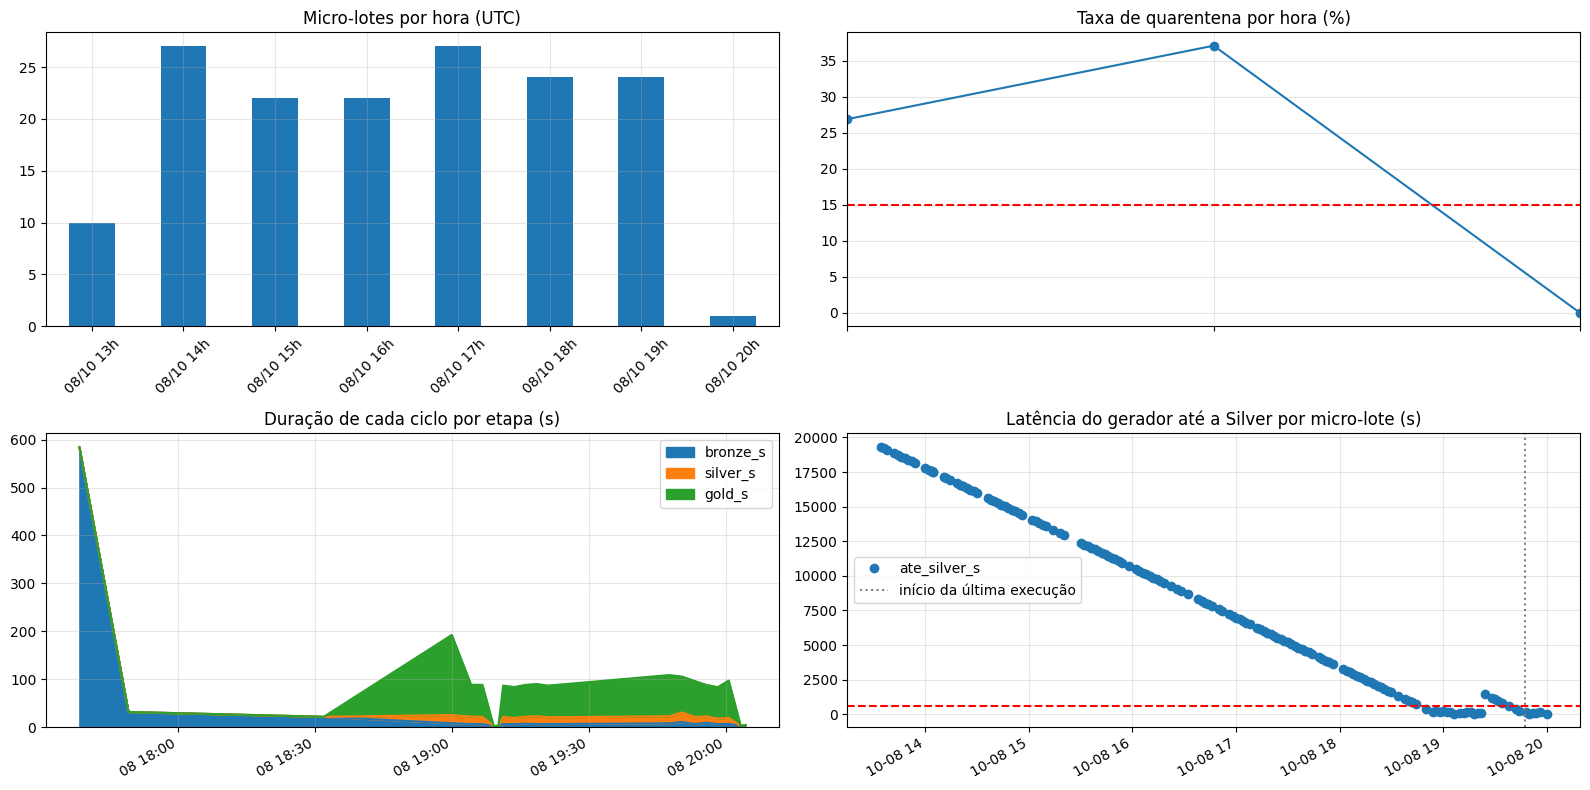

area,indicador,valor,situacao
Fonte,minutos desde o último micro-lote,4.7,✅
Ingestão,"micro-lotes do raw sem destino (nem Bronze, nem recusados)",0,✅
Ingestão,micro-lotes recusados pela Bronze (total),0,✅
Frescor,Silver em dia com a Bronze,Silver 2026-10-08 20:00:48.377687 · Bronze 2026-10-08 20:00:37.811849,✅
Frescor,Gold em dia com a Silver,Gold 2026-10-08 20:00:52 · Silver 2026-10-08 20:00:48.377687,✅
Frescor,idade do pedido mais recente mostrado nos KPIs (min),5.5,✅
Orquestração,ciclos nas últimas 24 h (com dados),23 (14),✅
Orquestração,ciclos com erro na última execução (orquestrador_20261008_194726),0,✅
Orquestração,ciclos com erro em execuções anteriores (histórico),5,⚠️
Orquestração,duração p95 dos ciclos com dados (s),137.8,✅


Veredito: ATENÇÃO · 0 ❌ · 3 ⚠️ · 13 ✅


In [0]:
painel = pd.DataFrame(saude)
criticos, avisos = int((painel["situacao"] == "❌").sum()), int((painel["situacao"] == "⚠️").sum())
VEREDITO = "AÇÃO NECESSÁRIA" if criticos else ("ATENÇÃO" if avisos else "SAUDÁVEL")

fig, eixos = plt.subplots(2, 2, figsize=(16, 8))
if len(fonte_por_hora):
    fonte_por_hora.plot.bar(x="janela_utc", y="micro_lotes", ax=eixos[0, 0], legend=False, title="Micro-lotes por hora (UTC)")
    eixos[0, 0].set_xticklabels([f"{t:%d/%m %Hh}" for t in fonte_por_hora["janela_utc"]], rotation=45)
else:
    eixos[0, 0].set_title("Nenhum micro-lote na janela observada")
if qualidade["taxa_pct"].notna().any():
    qualidade.plot(x="hora", y="taxa_pct", style="o-", ax=eixos[0, 1], legend=False, title="Taxa de quarentena por hora (%)")
    eixos[0, 1].axhline(LIMITES["quarentena_hora_pct"], color="red", linestyle="--")
else:
    eixos[0, 1].set_title("Nenhum pedido processado na janela observada")
if len(ciclos):
    ciclos.plot(x="inicio_utc", y=[f"{e}_s" for e in ETAPAS.values()], kind="area", stacked=True, ax=eixos[1, 0], title="Duração de cada ciclo por etapa (s)")
else:
    eixos[1, 0].set_title("Nenhum ciclo do orquestrador na janela observada")
if len(latencia) and latencia["ate_silver_s"].notna().any():
    latencia.sort_values("janela_utc").plot(x="janela_utc", y="ate_silver_s", style="o", ax=eixos[1, 1], legend=False,
                                            title="Latência do gerador até a Silver por micro-lote (s)")
    eixos[1, 1].axhline(LIMITES["latencia_silver_p95_s"], color="red", linestyle="--")
    if INICIO_ULTIMA is not None:
        eixos[1, 1].axvline(INICIO_ULTIMA, color="gray", linestyle=":", label="início da última execução"); eixos[1, 1].legend()
else:
    eixos[1, 1].set_title("Sem latência medida na janela observada")
for eixo in eixos.flat:
    eixo.grid(alpha=0.3)
    eixo.set_xlabel("")
plt.tight_layout(); plt.show()

# ------------------------------ resultado ------------------------------
display(painel)
print(f"Veredito: {VEREDITO} · {criticos} ❌ · {avisos} ⚠️ · {len(painel) - criticos - avisos} ✅")